# Router CNN + MCTS

Outline:
- 4.1 Imports & load dataset
- 4.2 Router CNN architecture
- 4.3 DataLoader & train/val split
- 4.4 Router CNN training
- 4.5 Helper functions (greedy_route, compute_overlaps_strict)
- 4.6 MCTS implementation
- 4.7 Smoke test
- 4.8 Full evaluation
- 4.9 Save checkpoint

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from copy import deepcopy
from typing import List, Tuple, Optional, Dict
from routing_env import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

gymnasium available
NumPy: 2.2.6
All imports OK
Grid: 5×5  |  Nets: 3  |  Channels: 7
State tensor shape: (7, 5, 5)
Using device: cuda


In [2]:
# Build working configs: only those with real mid-path overlaps
def compute_overlaps_strict(state, nets):
    pin_cells = set()
    for src, snk in nets:
        pin_cells.add(src)
        pin_cells.add(snk)
    congestion = state[C_CONGESTION]
    count = 0
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if congestion[r, c] > 1 and (r, c) not in pin_cells:
                count += 1
    return count

all_configs_m2 = generate_net_configs(min_manhattan=2, seed=42)
all_configs = []
for cfg in all_configs_m2:
    nets  = deepcopy(cfg)
    paths = route_all_nets_astar(GRID_SIZE, nets)
    state = build_state_tensor(nets, paths, GRID_SIZE)
    if compute_overlaps_strict(state, nets) > 0:
        all_configs.append(cfg)

print(f'Working configs (real overlaps): {len(all_configs)}')

# Load router dataset
with open('data/router_dataset.pkl', 'rb') as f:
    router_samples = pickle.load(f)

print(f'Router samples loaded: {len(router_samples):,}')
path_lengths = [s['path_length'] for s in router_samples]
print(f'Path lengths — min:{np.min(path_lengths)} max:{np.max(path_lengths)} mean:{np.mean(path_lengths):.2f}')

Working configs (real overlaps): 5000
Router samples loaded: 42,426
Path lengths — min:3 max:14 mean:4.89


## 4.2: Router CNN Architecture

Same backbone as the Cleaner CNN, but with two output heads:
- **Policy head**: probability distribution over grid moves (UP/DOWN/LEFT/RIGHT)
- **Value head**: scalar estimate V(s) used by MCTS for node evaluation

In [3]:
NUM_ACTIONS = 4  # UP, DOWN, LEFT, RIGHT

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class RouterCNN(nn.Module):
    """
    Shared backbone (4 conv blocks) with two heads:
      Policy head : logits over 4 directional actions
      Value head  : scalar state value in [-1, 1]
    """
    def __init__(self, in_channels=NUM_CHANNELS, num_actions=NUM_ACTIONS):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(in_channels, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )
        self._flat_size = 128 * GRID_SIZE * GRID_SIZE
        self.policy_head = nn.Sequential(
            nn.Linear(self._flat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_actions)
        )
        self.value_head = nn.Sequential(
            nn.Linear(self._flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x      = self.backbone(x)
        x      = x.view(x.size(0), -1)
        policy = self.policy_head(x)
        value  = self.value_head(x)
        return policy, value

    def predict(self, state_np):
        """Numpy in → (action_probs, value) out. Used by greedy_route and MCTS."""
        self.eval()
        with torch.no_grad():
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)
            policy_logits, value = self(x)
            probs = F.softmax(policy_logits, dim=1).cpu().numpy()[0]
            val   = value.cpu().numpy()[0, 0]
        return probs, val


# Sanity check
router_model = RouterCNN().to(device)
dummy = torch.zeros(2, NUM_CHANNELS, GRID_SIZE, GRID_SIZE).to(device)
p_out, v_out = router_model(dummy)
print(f'RouterCNN OK — policy:{p_out.shape}  value:{v_out.shape}')
print(f'Parameters: {sum(p.numel() for p in router_model.parameters()):,}')

RouterCNN OK — policy:torch.Size([2, 4])  value:torch.Size([2, 1])
Parameters: 2,559,173


## 4.3: Dataset and DataLoader

In [4]:
class RouterDataset(Dataset):
    """
    Expands each sample into one training example per path step,
    giving much richer and more diverse training signal.
    """
    def __init__(self, samples):
        states, actions, values = [], [], []
        for s in samples:
            path    = s['action_seq']
            state   = s['state']
            net_idx = s['net_idx']
            for step_idx, action in enumerate(path):
                partial = state.copy()
                partial[C_PATH_START + net_idx] = 0.0
                partial[C_CONGESTION] = partial[
                    C_PATH_START:C_PATH_START + NUM_NETS].sum(axis=0)
                states.append(partial)
                actions.append(action)
                remaining = len(path) - step_idx
                values.append(1.0 - (remaining / (GRID_SIZE * 2)))

        self.states  = torch.tensor(np.stack(states),  dtype=torch.float32)
        self.actions = torch.tensor(actions,            dtype=torch.long)
        self.values  = torch.tensor(values,             dtype=torch.float32)

    def __len__(self):
        return len(self.actions)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx], self.values[idx]


dataset    = RouterDataset(router_samples)
total      = len(dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE   = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Total samples : {total:,}')
print(f'Train         : {len(train_set):,}')
print(f'Val           : {len(val_set):,}')
print(f'Test          : {len(test_set):,}')

Total samples : 207,573
Train         : 166,058
Val           : 20,757
Test          : 20,758


## 4.4: Router CNN Training

In [6]:
NUM_EPOCHS    = 150
LEARNING_RATE = 1e-3
PATIENCE      = 40
POLICY_WEIGHT = 1.0
VALUE_WEIGHT  = 0.5

router_model     = RouterCNN().to(device)
optimizer        = optim.Adam(router_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler        = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
policy_criterion = nn.CrossEntropyLoss()
value_criterion  = nn.MSELoss()

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_loss  = float('inf')
patience_count = 0
os.makedirs('checkpoints', exist_ok=True)


def run_epoch(loader, train=True):
    router_model.train() if train else router_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for states, actions, values in loader:
            states  = states.to(device)
            actions = actions.to(device)
            values  = values.to(device)
            policy_logits, value_preds = router_model(states)
            loss = (POLICY_WEIGHT * policy_criterion(policy_logits, actions)
                  + VALUE_WEIGHT  * value_criterion(value_preds.squeeze(), values))
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(actions)
            correct    += (policy_logits.argmax(1) == actions).sum().item()
            total      += len(actions)
    return total_loss / total, correct / total


print(f'Starting Router training for {NUM_EPOCHS} epochs...')
print(f'{"Epoch":>6} {"Train Loss":>12} {"Train Acc":>10} {"Val Loss":>10} {"Val Acc":>9}')
print('-' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(router_model.state_dict(), 'checkpoints/router_best.pt')
        flag = ' <- best'
    else:
        patience_count += 1
        flag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} {train_loss:>12.4f} {train_acc*100:>9.1f}% '
              f'{val_loss:>10.4f} {val_acc*100:>8.1f}%{flag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')

Starting Router training for 150 epochs...
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------


     1       0.8904      57.1%     0.8504     57.1% <- best
     5       0.8303      58.3%     0.8380     57.3%
    10       0.8277      58.2%     0.8327     57.3% <- best
    15       0.8269      58.2%     0.8343     57.3%
    20       0.8268      58.2%     0.8337     57.4%
    25       0.8263      58.3%     0.8341     57.4%
    30       0.8263      58.2%     0.8328     57.4%
    35       0.8258      58.3%     0.8361     57.3%
    40       0.8253      58.3%     0.8326     57.1%
    45       0.8254      58.3%     0.8322     57.3%
    50       0.8254      58.3%     0.8332     57.3%
    55       0.8250      58.3%     0.8318     57.4%
    60       0.8250      58.3%     0.8326     57.5%
    65       0.8248      58.2%     0.8326     57.3%
    70       0.8244      58.4%     0.8334     57.3%
    75       0.8242      58.3%     0.8326     57.6%
    80       0.8239      58.4%     0.8354     57.5%

Early stopping at epoch 84

Training complete. Best val loss: 0.8317


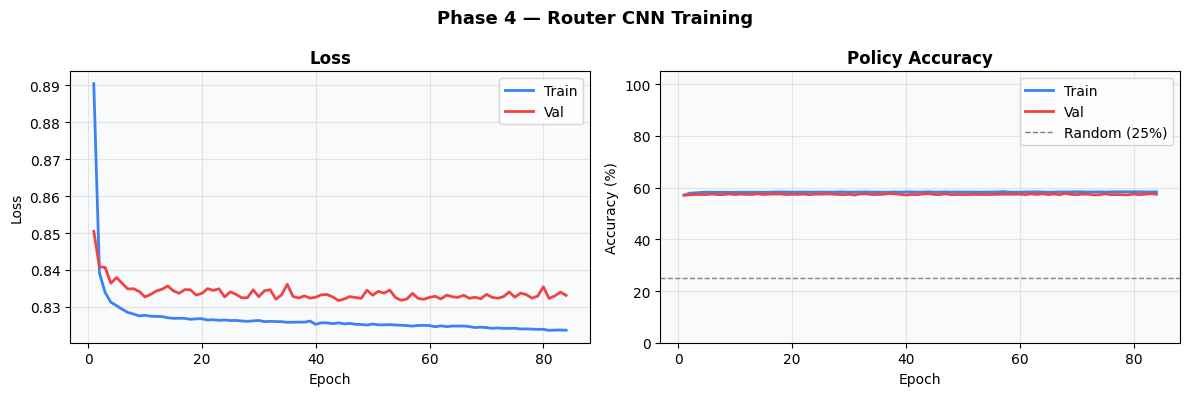

In [7]:
# Training curves
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phase 4 — Router CNN Training', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(epochs, history['train_loss'], color='#3B82F6', linewidth=2, label='Train')
ax.plot(epochs, history['val_loss'],   color='#EF4444', linewidth=2, label='Val')
ax.set_title('Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_facecolor('#F8FAFC')

ax = axes[1]
ax.plot(epochs, [a*100 for a in history['train_acc']], color='#3B82F6', linewidth=2, label='Train')
ax.plot(epochs, [a*100 for a in history['val_acc']],   color='#EF4444', linewidth=2, label='Val')
ax.axhline(y=25, color='gray', linestyle='--', linewidth=1, label='Random (25%)')
ax.set_title('Policy Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_facecolor('#F8FAFC')

plt.tight_layout()
plt.savefig('phase4_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
def greedy_route(model, nets, partial_paths, net_idx):
    """
    Route net_idx using Router CNN as greedy policy.
    Falls back to A* if CNN gets stuck.
    """
    src, snk = nets[net_idx]

    blocked = set()
    for i, p in enumerate(partial_paths):
        if p and i != net_idx:
            for cell in p:
                blocked.add(cell)
    blocked.discard(src)
    blocked.discard(snk)

    current   = src
    path      = [current]
    visited   = {current}
    max_steps = GRID_SIZE * GRID_SIZE

    for _ in range(max_steps):
        if current == snk:
            return path

        temp_paths = deepcopy(partial_paths)
        temp_paths[net_idx] = path
        current_state = build_state_tensor(nets, temp_paths, GRID_SIZE)

        valid_actions = []
        for action, (dr, dc) in ACTIONS.items():
            nr, nc = current[0] + dr, current[1] + dc
            if (0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE
                    and (nr, nc) not in blocked
                    and (nr, nc) not in visited):
                valid_actions.append(action)

        if not valid_actions:
            break

        probs, _    = model.predict(current_state)
        best_action = max(valid_actions, key=lambda a: probs[a])
        dr, dc      = ACTIONS[best_action]
        nxt         = (current[0] + dr, current[1] + dc)

        path.append(nxt)
        visited.add(nxt)
        current = nxt

    # CNN got stuck — fall back to A*
    return astar(GRID_SIZE, src, snk, blocked=blocked)


print("greedy_route ready")

greedy_route ready


## 4.4: Monte Carlo Tree Search (MCTS)

In [9]:
class MCTSNode:
    def __init__(self, position, parent=None, prior=0.0, action=None):
        self.position = position
        self.parent   = parent
        self.action   = action
        self.prior    = prior
        self.children: Dict = {}
        self.N = 0
        self.W = 0.0

    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0

    def is_leaf(self):
        return len(self.children) == 0

    def ucb_score(self, c_puct=1.4):
        if self.parent is None:
            return 0.0
        return self.Q + c_puct * self.prior * math.sqrt(self.parent.N) / (1 + self.N)


class MCTS:
    def __init__(self, model, grid_size=GRID_SIZE, c_puct=1.4, num_simulations=50):
        self.model           = model
        self.grid_size       = grid_size
        self.c_puct          = c_puct
        self.num_simulations = num_simulations

    def search(self, state, start, sink, blocked, path_so_far):
        root = MCTSNode(position=start)
        priors, _ = self.model.predict(state)
        self._expand(root, priors, blocked, set(path_so_far))
        for _ in range(self.num_simulations):
            node  = self._select(root)
            value = self._evaluate(node, state, sink)
            self._backpropagate(node, value)
        if not root.children:
            return np.random.randint(NUM_ACTIONS)
        return max(root.children, key=lambda a: root.children[a].N)

    def _select(self, node):
        while not node.is_leaf():
            node = max(node.children.values(), key=lambda n: n.ucb_score(self.c_puct))
        return node

    def _expand(self, node, priors, blocked, visited):
        r, c = node.position
        for action, (dr, dc) in ACTIONS.items():
            nr, nc   = r + dr, c + dc
            neighbor = (nr, nc)
            if not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size):
                continue
            if neighbor in blocked or neighbor in visited:
                continue
            node.children[action] = MCTSNode(
                position=neighbor, parent=node, prior=priors[action], action=action)

    def _evaluate(self, node, state, sink):
        if node.position == sink:
            return 1.0
        _, value   = self.model.predict(state)
        r, c       = node.position
        sr, sc     = sink
        dist       = abs(r - sr) + abs(c - sc)
        dist_bonus = 1.0 - dist / (2 * (self.grid_size - 1))
        return 0.7 * float(value) + 0.3 * dist_bonus

    def _backpropagate(self, node, value):
        while node is not None:
            node.N += 1
            node.W += value
            node    = node.parent


def mcts_route(model, nets, partial_paths, net_idx, num_simulations=50):
    src, snk = nets[net_idx]
    mcts     = MCTS(model, num_simulations=num_simulations)

    blocked = set()
    for i, p in enumerate(partial_paths):
        if p and i != net_idx:
            for cell in p:
                blocked.add(cell)
    blocked.discard(src)
    blocked.discard(snk)

    current   = src
    path      = [current]
    visited   = {current}
    max_steps = GRID_SIZE * GRID_SIZE

    for _ in range(max_steps):
        if current == snk:
            return path

        temp_paths = deepcopy(partial_paths)
        temp_paths[net_idx] = path
        current_state = build_state_tensor(nets, temp_paths, GRID_SIZE)

        valid_actions = []
        for action, (dr, dc) in ACTIONS.items():
            nr, nc = current[0] + dr, current[1] + dc
            if (0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE
                    and (nr, nc) not in blocked
                    and (nr, nc) not in visited):
                valid_actions.append(action)

        if not valid_actions:
            break

        action = mcts.search(current_state, current, snk, blocked, path)
        dr, dc = ACTIONS[action]
        nxt    = (current[0] + dr, current[1] + dc)

        # Fallback if MCTS picks invalid move
        if (nxt in blocked or nxt in visited
                or not (0 <= nxt[0] < GRID_SIZE and 0 <= nxt[1] < GRID_SIZE)):
            nxt = min(
                [(current[0]+ACTIONS[a][0], current[1]+ACTIONS[a][1]) for a in valid_actions],
                key=lambda p: abs(p[0]-snk[0]) + abs(p[1]-snk[1])
            )

        path.append(nxt)
        visited.add(nxt)
        current = nxt

    return path if current == snk else None


print('MCTS ready')

MCTS ready


In [10]:
class CleanerCNN(nn.Module):
    def __init__(self, in_channels=NUM_CHANNELS, num_classes=NUM_NETS):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            ConvBlock(in_channels, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )
        self._flat_size = 128 * GRID_SIZE * GRID_SIZE
        self.dense_blocks = nn.Sequential(
            nn.Linear(self._flat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, NUM_NETS)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        return self.dense_blocks(x)

    def predict_net(self, state_np):
        self.eval()
        with torch.no_grad():
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)
            return self(x).argmax(dim=1).item()


cleaner_model = CleanerCNN().to(device)
cleaner_model.load_state_dict(
    torch.load('checkpoints/cleaner_best.pt', map_location=device))
cleaner_model.eval()
print("Cleaner model loaded")

Cleaner model loaded


## MCTS-Guided Routing Evaluation

In [11]:
router_model.load_state_dict(
    torch.load('checkpoints/router_best.pt', map_location=device))
router_model.eval()

# Find a config with real overlaps
for i, cfg in enumerate(all_configs):
    test_nets  = deepcopy(cfg)
    test_paths = route_all_nets_astar(GRID_SIZE, test_nets)
    test_state = build_state_tensor(test_nets, test_paths, GRID_SIZE)
    if compute_overlaps_strict(test_state, test_nets) > 0:
        print(f"Config {i} — real overlaps: {compute_overlaps_strict(test_state, test_nets)}")
        break

# Cleaner picks net to remove
net_to_remove = cleaner_model.predict_net(test_state)
print(f"Cleaner removing Net {net_to_remove}")

partial_paths = deepcopy(test_paths)
partial_paths[net_to_remove] = None

# Router re-routes
greedy_path = greedy_route(router_model, test_nets, partial_paths, net_to_remove)

if greedy_path:
    partial_paths[net_to_remove] = greedy_path
    final_state = build_state_tensor(test_nets, partial_paths, GRID_SIZE)
    print(f"Path length    : {len(greedy_path)-1}")
    print(f"Final overlaps : {compute_overlaps_strict(final_state, test_nets)}")
    print(f"Success        : {compute_overlaps_strict(final_state, test_nets) == 0}")
else:
    print("Routing failed")

Config 0 — real overlaps: 1
Cleaner removing Net 1
Path length    : 8
Final overlaps : 0
Success        : True


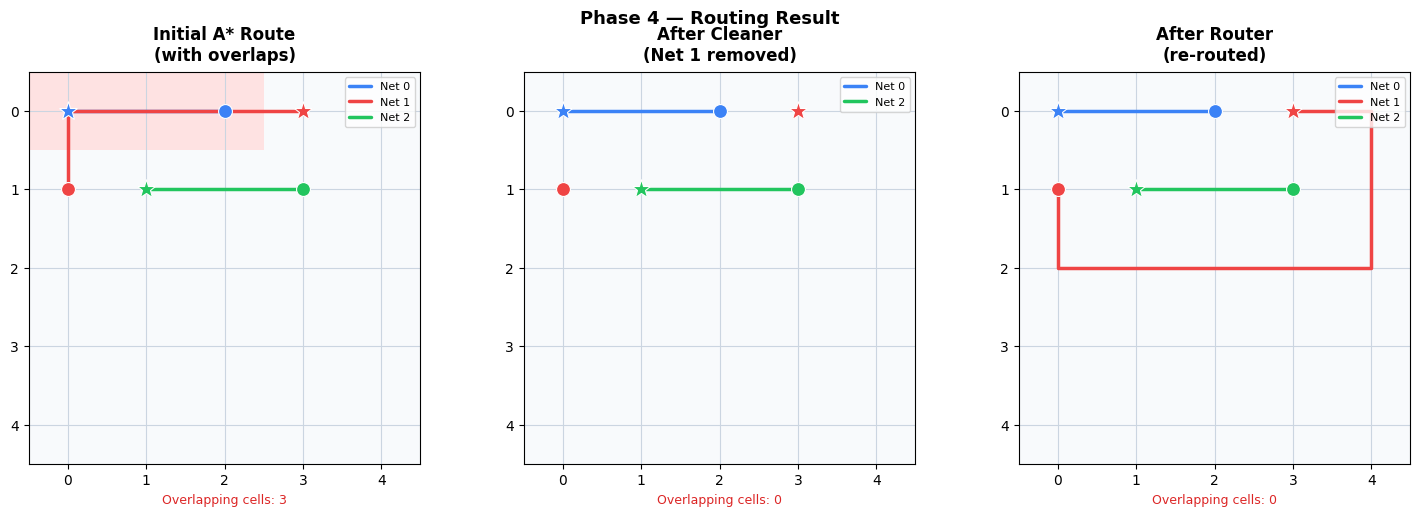

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Phase 4 — Routing Result', fontsize=13, fontweight='bold')

render_grid(test_nets, test_paths,
            title='Initial A* Route\n(with overlaps)', ax=axes[0])

temp = deepcopy(test_paths)
temp[net_to_remove] = None
render_grid(test_nets, temp,
            title=f'After Cleaner\n(Net {net_to_remove} removed)', ax=axes[1])

render_grid(test_nets, partial_paths,
            title='After Router\n(re-routed)', ax=axes[2])

plt.tight_layout()
plt.savefig('phase4_routing_result.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
rl_completed, astar_completed, total_tested = 0, 0, 0
cleaner_correct = 0
rl_wirelengths, astar_wirelengths = [], []

for cfg in all_configs[:200]:
    nets  = deepcopy(cfg)
    paths = route_all_nets_astar(GRID_SIZE, nets)
    state = build_state_tensor(nets, paths, GRID_SIZE)

    if compute_overlaps_strict(state, nets) == 0:
        continue

    total_tested += 1

    # --- A* baseline: remove each net, re-route with A*, take best result ---
    best_astar_paths   = None
    best_astar_overlaps = 999
    for net_rem in range(NUM_NETS):
        test_paths = deepcopy(paths)
        test_paths[net_rem] = None
        blocked = set()
        for i, p in enumerate(test_paths):
            if p:
                for cell in p: blocked.add(cell)
        src, snk = nets[net_rem]
        blocked.discard(src); blocked.discard(snk)
        new_path = astar(GRID_SIZE, src, snk, blocked=blocked)
        if new_path:
            test_paths[net_rem] = new_path
            test_state = build_state_tensor(nets, test_paths, GRID_SIZE)
            ov = compute_overlaps_strict(test_state, nets)
            if ov < best_astar_overlaps:
                best_astar_overlaps = ov
                best_astar_paths    = test_paths

    if best_astar_paths and best_astar_overlaps == 0:
        astar_completed += 1
        astar_wirelengths.append(compute_total_wirelength(best_astar_paths))

    # --- Find which net removal actually solves it (ground truth) ---
    best_net = None
    for net_rem in range(NUM_NETS):
        test_paths = deepcopy(paths)
        test_paths[net_rem] = None
        blocked = set()
        for i, p in enumerate(test_paths):
            if p:
                for cell in p: blocked.add(cell)
        src, snk = nets[net_rem]
        blocked.discard(src); blocked.discard(snk)
        new_path = astar(GRID_SIZE, src, snk, blocked=blocked)
        if new_path:
            test_paths[net_rem] = new_path
            test_state = build_state_tensor(nets, test_paths, GRID_SIZE)
            if compute_overlaps_strict(test_state, nets) == 0:
                best_net = net_rem
                break

    cleaner_pick = cleaner_model.predict_net(state)
    if best_net is not None and cleaner_pick == best_net:
        cleaner_correct += 1

    # --- RL pipeline: Cleaner picks net, Router re-routes ---
    rl_paths = deepcopy(paths)
    for _ in range(3):
        rl_state = build_state_tensor(nets, rl_paths, GRID_SIZE)
        if compute_overlaps_strict(rl_state, nets) == 0:
            break
        net_rem       = cleaner_model.predict_net(rl_state)
        rl_paths[net_rem] = None
        new_path      = greedy_route(router_model, nets, rl_paths, net_rem)
        if new_path:
            rl_paths[net_rem] = new_path

    rl_state = build_state_tensor(nets, rl_paths, GRID_SIZE)
    if compute_overlaps_strict(rl_state, nets) == 0 and all(p for p in rl_paths):
        rl_completed += 1
        rl_wirelengths.append(compute_total_wirelength(rl_paths))

print(f"Configs tested           : {total_tested}")
print()
print(f"Cleaner accuracy (net)   : {cleaner_correct/total_tested*100:.1f}%")
print()
print(f"A* completion rate       : {astar_completed/total_tested*100:.1f}%")
if astar_wirelengths:
    print(f"A* avg wirelength        : {np.mean(astar_wirelengths):.2f}")
print()
print(f"RL completion rate       : {rl_completed/total_tested*100:.1f}%")
if rl_wirelengths:
    print(f"RL avg wirelength        : {np.mean(rl_wirelengths):.2f}")

Configs tested           : 200

Cleaner accuracy (net)   : 60.5%

A* completion rate       : 70.5%
A* avg wirelength        : 10.45

RL completion rate       : 62.5%
RL avg wirelength        : 13.66


In [16]:
checkpoint = {
    'model_state_dict':     router_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history':              history,
    'best_val_loss':        best_val_loss,
    'config': {
        'in_channels':  NUM_CHANNELS,
        'num_actions':  NUM_ACTIONS,
        'grid_size':    GRID_SIZE,
        'num_epochs':   NUM_EPOCHS,
        'lr':           LEARNING_RATE,
        'batch_size':   BATCH_SIZE,
    }
}
torch.save(checkpoint, 'checkpoints/router_final.pt')
print("Checkpoint saved to checkpoints/router_final.pt")
print()
print("  Phase 4 Summary")
print(f"  Architecture : 4 conv + policy & value heads")
print(f"  Parameters   : {sum(p.numel() for p in router_model.parameters()):,}")
print(f"  Best val loss: {best_val_loss:.4f}")
print(f"  Checkpoint   : checkpoints/router_best.pt")
print()
print("  Ready for Phase 5: Co-Training & Evaluation")

Checkpoint saved to checkpoints/router_final.pt

  Phase 4 Summary
  Architecture : 4 conv + policy & value heads
  Parameters   : 2,559,173
  Best val loss: 0.8317
  Checkpoint   : checkpoints/router_best.pt

  Ready for Phase 5: Co-Training & Evaluation
